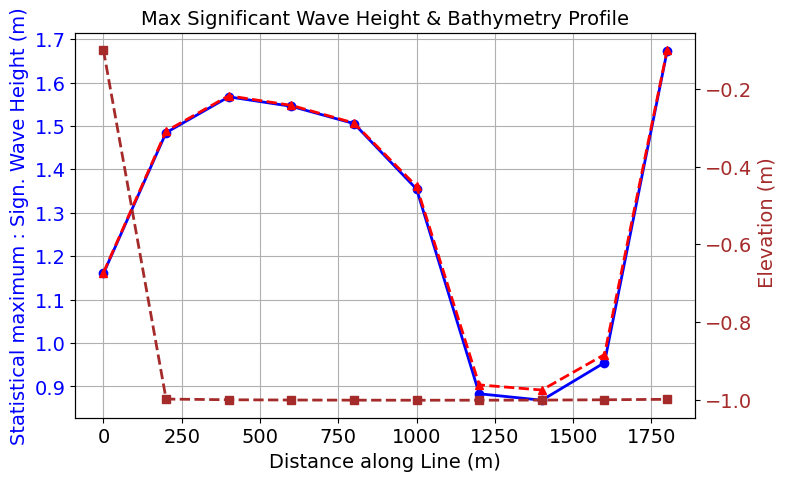

In [1]:
import mikeio
import matplotlib.pyplot as plt
import numpy as np

# File paths
wave_ht_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Stat_dfsu\max_sig_wave_ht_line_altered_west_side_0.1m_Kn.dfs1"
wave_ht_file_altered = r"D:\Phd Research\Wave Model\small scale port lavaca\Stat_dfsu\max_sig_wave_ht_line_altered_west_side.dfs1"
bathy_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Stat_dfsu\Cross-shore_bathymetry_west_side.dfs1"

# Read DFS1 files
wave_dfs = mikeio.open(wave_ht_file)
wave_dfs_altered = mikeio.open(wave_ht_file_altered)
bathy_dfs = mikeio.open(bathy_file)

# Select the first variable in each file
wave_item_index = 1  # Adjust index if needed
bathy_item_index = 0

# Read data
wave_data = wave_dfs.read(items=[wave_item_index])
wave_data_altered = wave_dfs_altered.read(items=[wave_item_index])
bathy_data = bathy_dfs.read(items=[bathy_item_index])

# Convert to NumPy arrays
wave_values = wave_data[0].to_numpy().flatten()
wave_values_altered = wave_data_altered[0].to_numpy().flatten()
bathy_values = bathy_data[0].to_numpy().flatten()

# Define X-axis (assuming same number of points in all datasets)
num_points = len(wave_values)
x_axis = np.arange(num_points) * 200  # Convert index to meters (1 unit = 200m)
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})
# Create figure and axes
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot wave heights (left Y-axis)
ax1.plot(x_axis, wave_values, marker="o", linestyle="-", color="b", linewidth=2, label="Max Sig. Wave Height (Original)")
ax1.plot(x_axis, wave_values_altered, marker="^", linestyle="--", color="r", linewidth=2, label="Max Sig. Wave Height (Altered)")
ax1.set_xlabel("Distance along Line (m)")
ax1.set_ylabel(f"{wave_dfs.items[wave_item_index].name} (m)", color="b")
ax1.tick_params(axis="y", labelcolor="b")

# Plot bathymetry (right Y-axis)
ax2 = ax1.twinx()
ax2.plot(x_axis, bathy_values, marker="s", linestyle="--", color="brown", linewidth=2, label="Bathymetry")
ax2.set_ylabel(f"{bathy_dfs.items[bathy_item_index].name} Elevation (m)", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

# Combine legends into one box and place it manually
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines.extend(lines2)
labels.extend(labels2)

#fig.legend(lines, labels, loc="upper right", bbox_to_anchor=(0.85, 0.75), frameon=True)

# Grid and title
plt.title("Max Significant Wave Height & Bathymetry Profile")
ax1.grid(True)

# Show plot
plt.show()


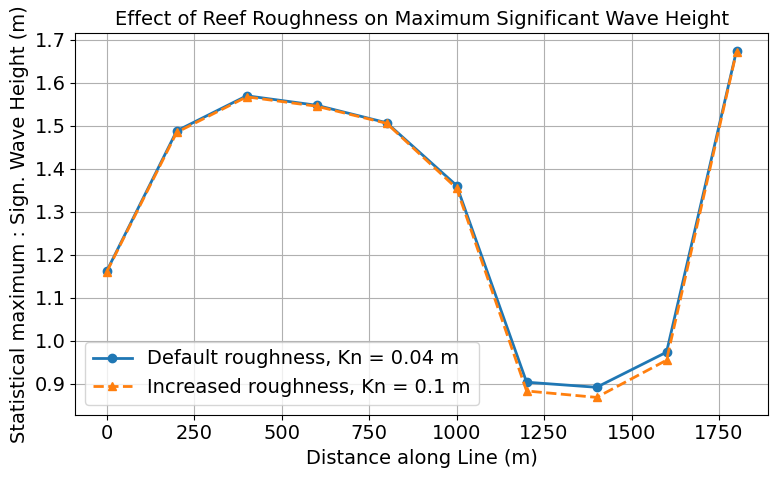

In [2]:
import mikeio
import matplotlib.pyplot as plt
import numpy as np

# File paths
wave_ht_file_default = r"D:\Phd Research\Wave Model\small scale port lavaca\Stat_dfsu\max_sig_wave_ht_line_altered_west_side.dfs1"  # default roughness 0.04 m
wave_ht_file_rough = r"D:\Phd Research\Wave Model\small scale port lavaca\Stat_dfsu\max_sig_wave_ht_line_altered_west_side_0.1m_Kn - Copy.dfs1"  # roughness 0.1 m

# Read DFS1 files
wave_dfs_default = mikeio.open(wave_ht_file_default)
wave_dfs_rough = mikeio.open(wave_ht_file_rough)

# Select item index
wave_item_index = 1  # Adjust if needed

# Read data
wave_data_default = wave_dfs_default.read(items=[wave_item_index])
wave_data_rough = wave_dfs_rough.read(items=[wave_item_index])

# Convert to NumPy arrays
wave_values_default = wave_data_default[0].to_numpy().flatten()
wave_values_rough = wave_data_rough[0].to_numpy().flatten()

# Define X-axis
num_points = min(len(wave_values_default), len(wave_values_rough))
x_axis = np.arange(num_points) * 200  # 1 point = 200 m

# Match lengths
wave_values_default = wave_values_default[:num_points]
wave_values_rough = wave_values_rough[:num_points]

# Plot settings
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Plot wave height comparison
ax.plot(
    x_axis,
    wave_values_default,
    marker="o",
    linestyle="-",
    linewidth=2,
    label="Default roughness, Kn = 0.04 m"
)

ax.plot(
    x_axis,
    wave_values_rough,
    marker="^",
    linestyle="--",
    linewidth=2,
    label="Increased roughness, Kn = 0.1 m"
)

# Labels and title
ax.set_xlabel("Distance along Line (m)")
ax.set_ylabel(f"{wave_dfs_default.items[wave_item_index].name} (m)")
ax.set_title("Effect of Reef Roughness on Maximum Significant Wave Height")

# Grid and legend
ax.grid(True)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU file
dfsu_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

# Transect
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)

# Read dfsu
dfs = mikeio.open(dfsu_file)

ds = dfs.read(items=["Sign. Wave Height"])

# Select time
target_time = np.datetime64("2017-08-26T02:30:00")

time_index = np.argmin(np.abs(ds.time.values - target_time))

# Extract single timestep
da = ds[0].isel(time=time_index)

# Interpolate along line
hs_profile = da.interp(
    x=x_line,
    y=y_line
).to_numpy()

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(8,5))
plt.plot(distance, hs_profile, linewidth=2)

plt.xlabel("Distance Along Transect (m)")
plt.ylabel("Significant Wave Height (m)")
plt.title("Significant Wave Height Along Transect\n26-Aug-2017 02:30")
plt.grid(True)

plt.tight_layout()
plt.show()

ValueError: x must consist of vectors of length 2 but has shape (1, 2, 200)

Selected timestep: 2017-08-26T02:30:00.000000000


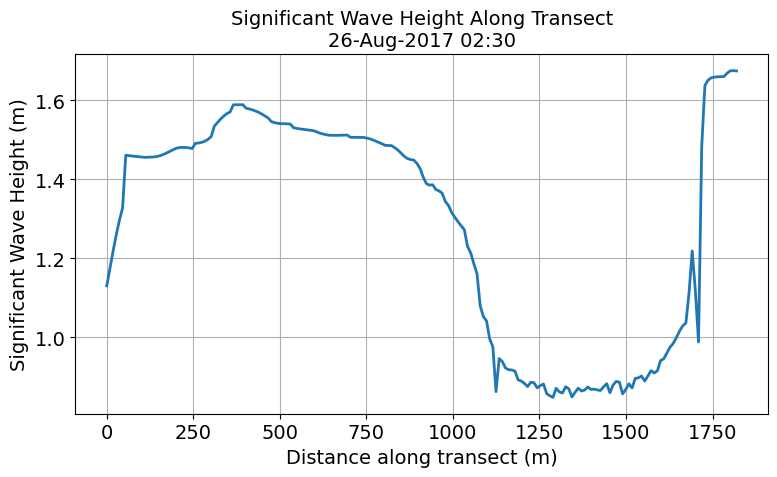

In [7]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU file
dfsu_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

# Number of sampling points along transect
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Open DFSU
dfs = mikeio.open(dfsu_file)

# Read Sign. Wave Height
ds = dfs.read(items=["Sign. Wave Height"])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Find nearest timestep
time_index = np.argmin(np.abs(ds.time.values - target_time))
selected_time = ds.time.values[time_index]

print("Selected timestep:", selected_time)

# Extract data at selected timestep
da = ds["Sign. Wave Height"].isel(time=time_index)

# Get spatial interpolant
elem_ids, weights = da.geometry.get_2d_interpolant(
    coords,
    n_nearest=3,
    extrapolate=False
)

# Interpolate Hs along transect
hs_profile = da.geometry.interp2d(
    da,
    elem_ids,
    weights
).flatten()

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(distance, hs_profile, linewidth=2)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Significant Wave Height (m)")
plt.title("Significant Wave Height Along Transect\n26-Aug-2017 02:30")
plt.grid(True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.1 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000


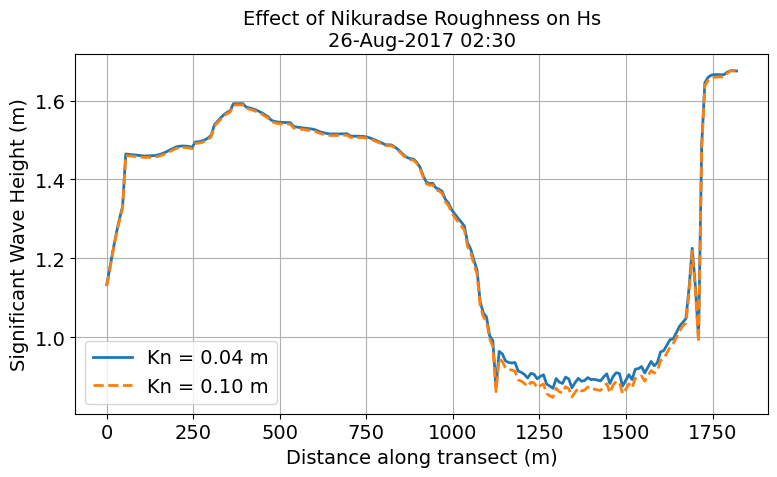

In [8]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_01 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_hs_profile(dfsu_file, item_name="Sign. Wave Height"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    hs_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return hs_profile, selected_time

# Extract profiles
hs_01, time_01 = extract_hs_profile(dfsu_file_01)
hs_004, time_004 = extract_hs_profile(dfsu_file_004)

print("Selected timestep for Kn = 0.1 m:", time_01)
print("Selected timestep for Kn = 0.04 m:", time_004)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    distance,
    hs_004,
    linewidth=2,
    label="Kn = 0.04 m"
)

plt.plot(
    distance,
    hs_01,
    linewidth=2,
    linestyle="--",
    label="Kn = 0.10 m"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Significant Wave Height (m)")
plt.title("Effect of Nikuradse Roughness on Hs\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


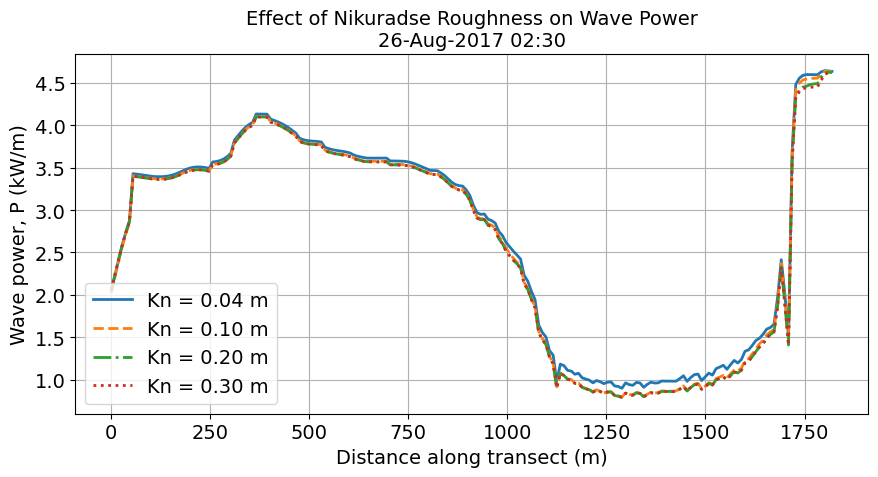

In [17]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Wave power, p"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract wave power profiles
p_004, time_004 = extract_profile(dfsu_file_004)
p_01,  time_01  = extract_profile(dfsu_file_01)
p_02,  time_02  = extract_profile(dfsu_file_02)
p_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, p_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, p_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, p_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, p_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Wave power, P (kW/m)")
plt.title("Effect of Nikuradse Roughness on Wave Power\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


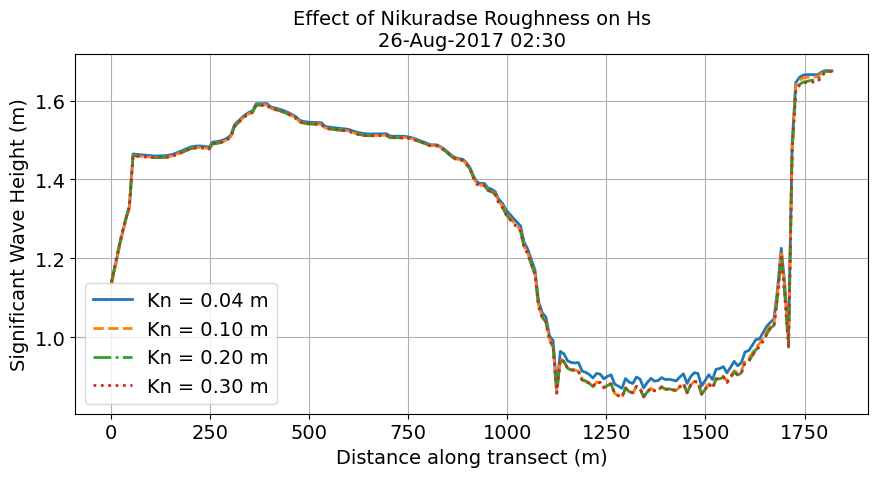

In [15]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

# Check this file path: currently same as Kn = 0.2 m
dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

target_time = np.datetime64("2017-08-26T02:30:00")

def extract_hs_profile(dfsu_file, item_name="Sign. Wave Height"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    hs_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return hs_profile, selected_time

# Extract profiles
hs_004, time_004 = extract_hs_profile(dfsu_file_004)
hs_01, time_01 = extract_hs_profile(dfsu_file_01)
hs_02, time_02 = extract_hs_profile(dfsu_file_02)
hs_03, time_03 = extract_hs_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

plt.figure(figsize=(9, 5))

plt.plot(distance, hs_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, hs_01, linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, hs_02, linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, hs_03, linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Significant Wave Height (m)")
plt.title("Effect of Nikuradse Roughness on Hs\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


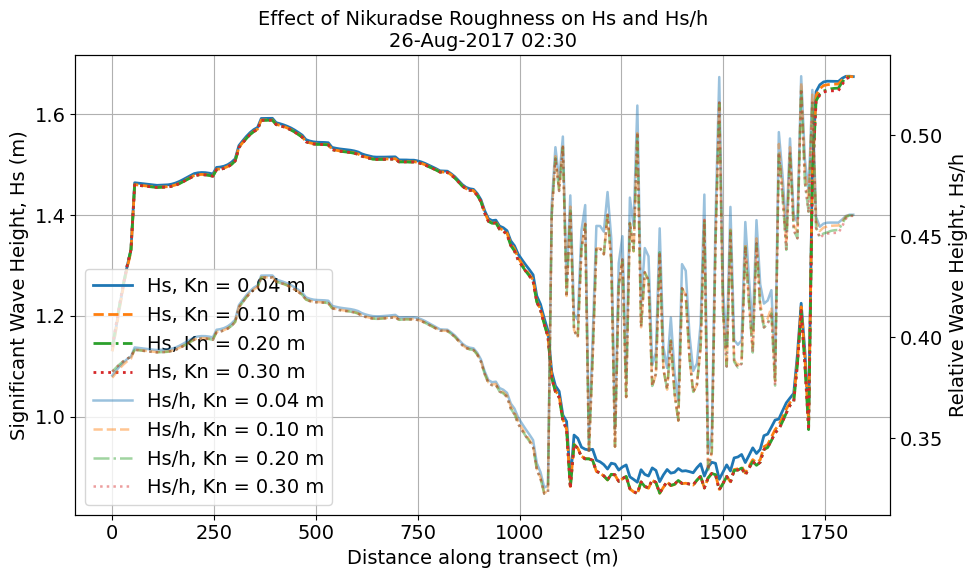

In [16]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

# Check this file path: currently same as Kn = 0.2 m
dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

target_time = np.datetime64("2017-08-26T02:30:00")

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile from one file
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero
depth_profile = np.maximum(depth_profile, 0.01)

# Calculate Hs / water depth
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: Hs
ax1.plot(distance, hs_004, linewidth=2, label="Hs, Kn = 0.04 m")
ax1.plot(distance, hs_01,  linewidth=2, linestyle="--", label="Hs, Kn = 0.10 m")
ax1.plot(distance, hs_02,  linewidth=2, linestyle="-.", label="Hs, Kn = 0.20 m")
ax1.plot(distance, hs_03,  linewidth=2, linestyle=":", label="Hs, Kn = 0.30 m")

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Significant Wave Height, Hs (m)")
ax1.grid(True)

# Secondary axis: Hs / h
ax2 = ax1.twinx()

ax2.plot(distance, ratio_004, linewidth=1.8, alpha=0.45, label="Hs/h, Kn = 0.04 m")
ax2.plot(distance, ratio_01,  linewidth=1.8, alpha=0.45, linestyle="--", label="Hs/h, Kn = 0.10 m")
ax2.plot(distance, ratio_02,  linewidth=1.8, alpha=0.45, linestyle="-.", label="Hs/h, Kn = 0.20 m")
ax2.plot(distance, ratio_03,  linewidth=1.8, alpha=0.45, linestyle=":", label="Hs/h, Kn = 0.30 m")

ax2.set_ylabel("Relative Wave Height, Hs/h")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Effect of Nikuradse Roughness on Hs and Hs/h\n26-Aug-2017 02:30")
plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


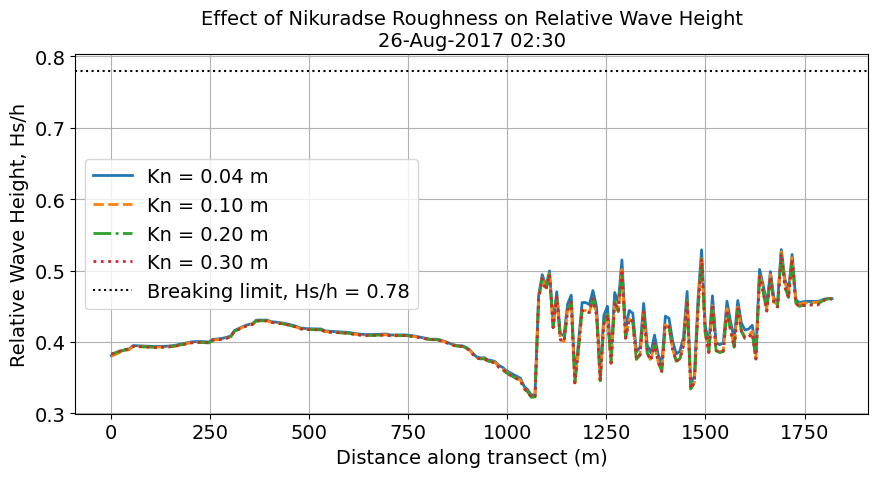

In [14]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hs/h")
plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


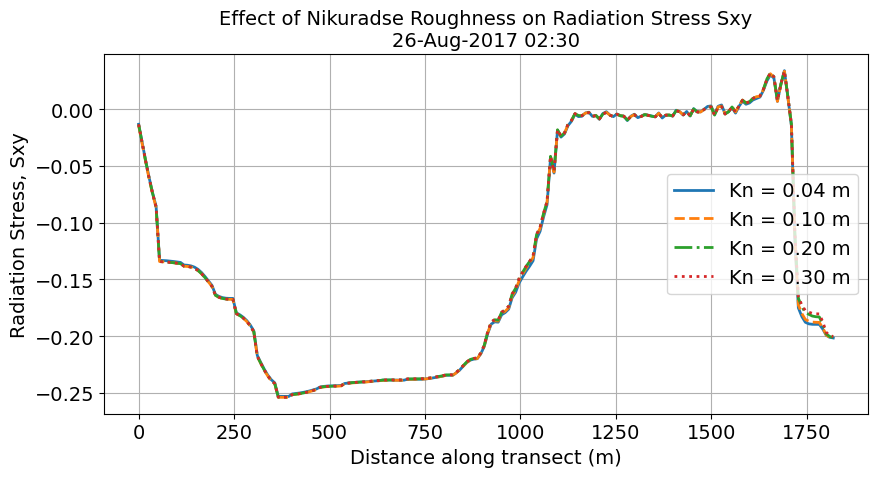

In [18]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

# Number of sampling points
n_points = 200

# Generate transect coordinates
x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Function to extract profile
def extract_profile(dfsu_file, item_name="Rad. Stress, Sxy"):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract radiation stress profiles
sxy_004, time_004 = extract_profile(dfsu_file_004)
sxy_01,  time_01  = extract_profile(dfsu_file_01)
sxy_02,  time_02  = extract_profile(dfsu_file_02)
sxy_03,  time_03  = extract_profile(dfsu_file_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# Plot
plt.figure(figsize=(9, 5))

plt.plot(distance, sxy_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, sxy_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, sxy_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, sxy_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Radiation Stress, Sxy")
plt.title("Effect of Nikuradse Roughness on Radiation Stress Sxy\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


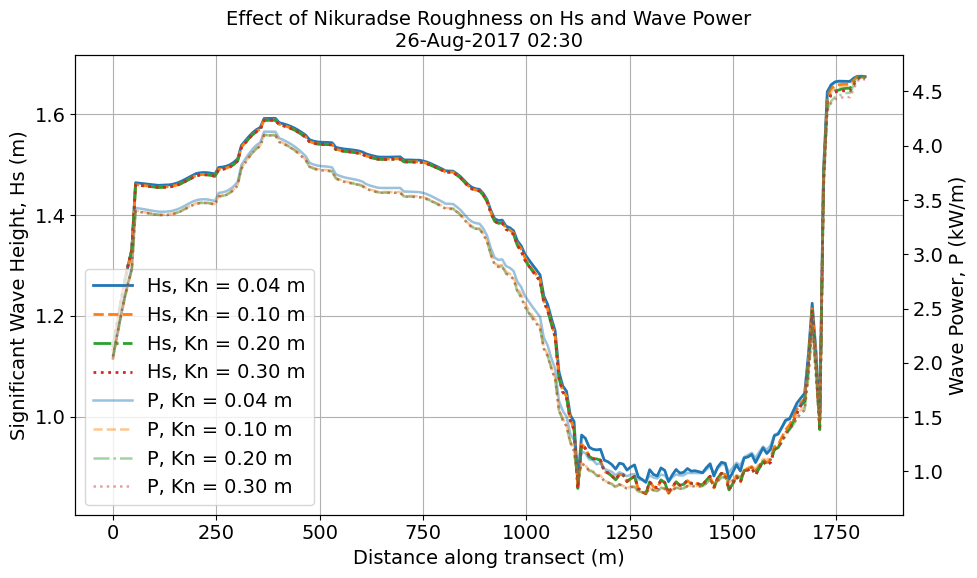

In [19]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

target_time = np.datetime64("2017-08-26T02:30:00")

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract wave power profiles
p_004, _ = extract_profile(dfsu_file_004, "Wave power, p")
p_01,  _ = extract_profile(dfsu_file_01,  "Wave power, p")
p_02,  _ = extract_profile(dfsu_file_02,  "Wave power, p")
p_03,  _ = extract_profile(dfsu_file_03,  "Wave power, p")

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: Significant wave height
ax1.plot(distance, hs_004, linewidth=2, label="Hs, Kn = 0.04 m")
ax1.plot(distance, hs_01,  linewidth=2, linestyle="--", label="Hs, Kn = 0.10 m")
ax1.plot(distance, hs_02,  linewidth=2, linestyle="-.", label="Hs, Kn = 0.20 m")
ax1.plot(distance, hs_03,  linewidth=2, linestyle=":", label="Hs, Kn = 0.30 m")

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Significant Wave Height, Hs (m)")
ax1.grid(True)

# Secondary axis: Wave power
ax2 = ax1.twinx()

ax2.plot(distance, p_004, linewidth=1.8, alpha=0.45, label="P, Kn = 0.04 m")
ax2.plot(distance, p_01,  linewidth=1.8, alpha=0.45, linestyle="--", label="P, Kn = 0.10 m")
ax2.plot(distance, p_02,  linewidth=1.8, alpha=0.45, linestyle="-.", label="P, Kn = 0.20 m")
ax2.plot(distance, p_03,  linewidth=1.8, alpha=0.45, linestyle=":", label="P, Kn = 0.30 m")

ax2.set_ylabel("Wave Power, P (kW/m)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Effect of Nikuradse Roughness on Hs and Wave Power\n26-Aug-2017 02:30")
plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


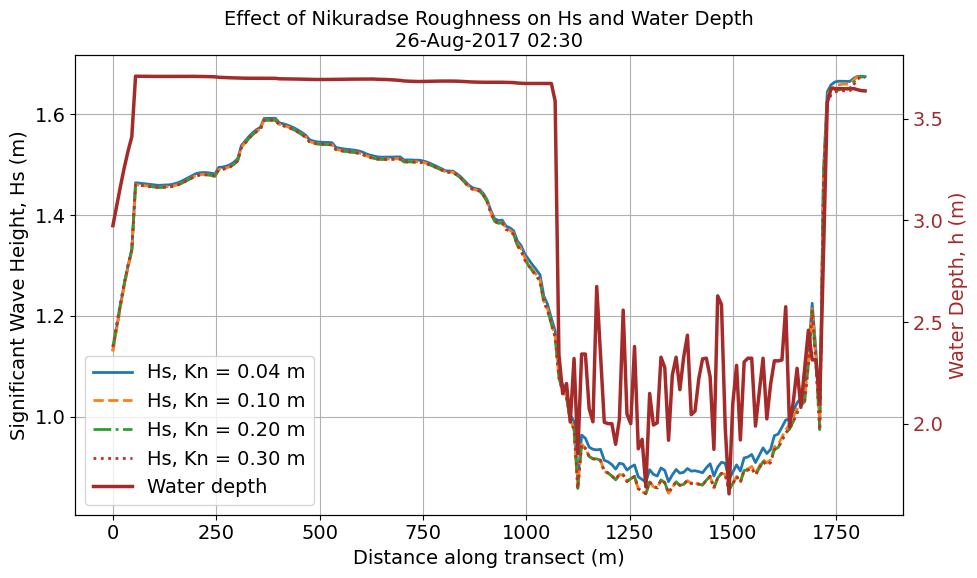

In [20]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Sign. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Sign. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Sign. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Sign. Wave Height")

# Extract water depth profile
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot Hs and water depth
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: Significant wave height
ax1.plot(distance, hs_004, linewidth=2, label="Hs, Kn = 0.04 m")
ax1.plot(distance, hs_01,  linewidth=2, linestyle="--", label="Hs, Kn = 0.10 m")
ax1.plot(distance, hs_02,  linewidth=2, linestyle="-.", label="Hs, Kn = 0.20 m")
ax1.plot(distance, hs_03,  linewidth=2, linestyle=":", label="Hs, Kn = 0.30 m")

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Significant Wave Height, Hs (m)")
ax1.grid(True)

# Secondary axis: Water depth
ax2 = ax1.twinx()

ax2.plot(
    distance,
    depth_profile,
    color="brown",
    linewidth=2.5,
    label="Water depth"
)

ax2.set_ylabel("Water Depth, h (m)", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

# Optional: invert water-depth axis so shallow reef appears upward
# ax2.invert_yaxis()

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Effect of Nikuradse Roughness on Hs and Water Depth\n26-Aug-2017 02:30")

plt.tight_layout()
plt.show()

Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000
Selected timestep water depth: 2017-08-26T02:30:00.000000000


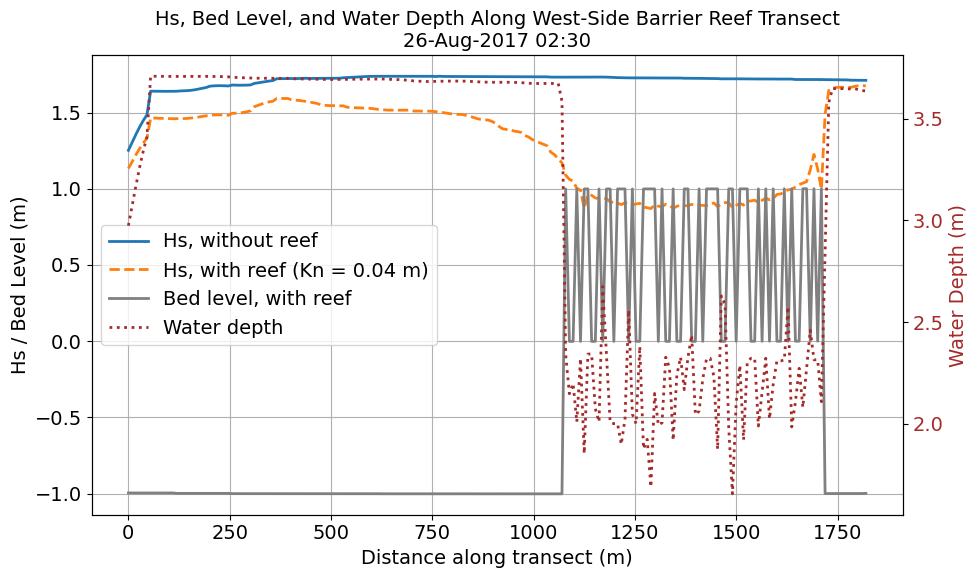

In [23]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition: west-side fringing reef, Kn = 0.04 m
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# With reef bathymetry mesh
mesh_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\updated_bathymetry_west_side.mesh"

# Without reef bathymetry DFSU
bathy_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from mesh
# =========================
def extract_bed_from_mesh(mesh_file):
    geom = mikeio.Mesh(mesh_file).geometry

    # In MIKE mesh, node z is usually bed level/elevation
    node_x = geom.node_coordinates[:, 0]
    node_y = geom.node_coordinates[:, 1]
    node_z = geom.node_coordinates[:, 2]

    # Use nearest node interpolation for bed level
    from scipy.spatial import cKDTree

    tree = cKDTree(np.column_stack([node_x, node_y]))
    _, idx = tree.query(coords)

    bed_profile = node_z[idx]

    return bed_profile


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu_bathy(dfsu_file):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, item in enumerate(dfs.items):
        print(i, item.name)

    # Change item name below if needed after checking printed item names
    ds = dfs.read(items=[0])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

# Hs profiles
hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Sign. Wave Height",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Sign. Wave Height",
    target_time
)

# Water depth profile from reef simulation
water_depth_reef, time_depth = extract_dfsu_profile(
    dfsu_reef,
    "Water depth",
    target_time
)

# Bed levels
bed_reef = extract_bed_from_mesh(mesh_reef)

# Use this if you also want to compare existing bathymetry
# bed_no_reef = extract_bed_from_dfsu_bathy(bathy_no_reef)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)
print("Selected timestep water depth:", time_depth)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Hs and bed level
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Hs, without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Hs, with reef (Kn = 0.04 m)"
)

ax1.plot(
    distance,
    bed_reef,
    linewidth=2,
    color="grey",
    label="Bed level, with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Hs / Bed Level (m)")
ax1.grid(True)

# Secondary y-axis: water depth
ax2 = ax1.twinx()

ax2.plot(
    distance,
    water_depth_reef,
    linewidth=2,
    linestyle=":",
    color="brown",
    label="Water depth"
)

ax2.set_ylabel("Water Depth (m)", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Hs, Bed Level, and Water Depth Along West-Side Barrier Reef Transect\n26-Aug-2017 02:30")

plt.tight_layout()
plt.show()

Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000
Selected timestep water depth: 2017-08-26T02:30:00.000000000


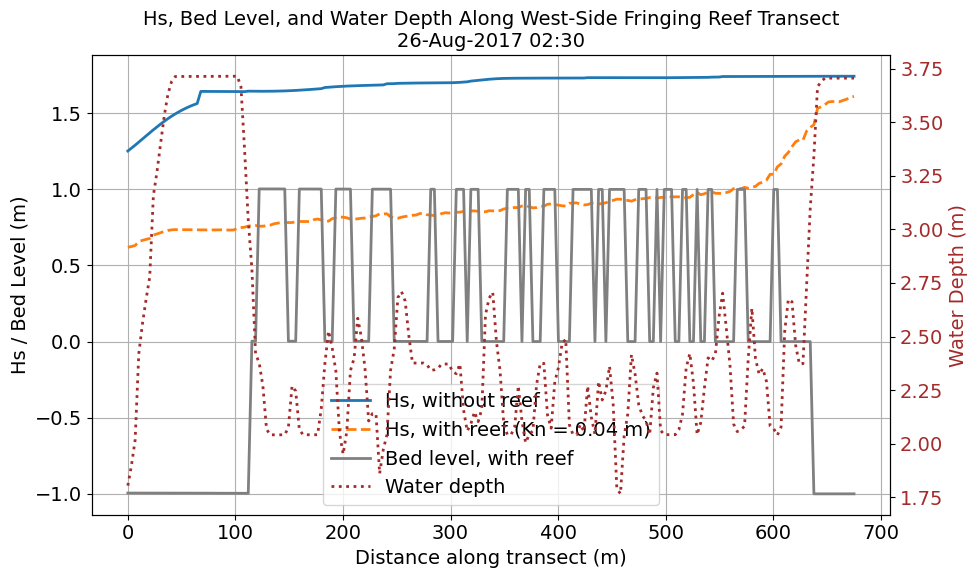

In [24]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# =========================
# File paths
# =========================

# With reef condition: west-side fringing reef, Kn = 0.04 m
dfsu_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef.sw - Result Files\west_side_fringing_reef.dfsu"

# Without reef condition
dfsu_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# With reef bathymetry mesh
mesh_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\updated_bathymetry_west_side_fringing_reef.mesh"

# Without reef bathymetry DFSU
bathy_no_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Mesh file\existing_topo_bathy_port_lavaca.dfsu"

# =========================
# Transect endpoints
# =========================
x1, y1 = 729827, 3174795
x2, y2 = 730232, 3175335

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

# =========================
# Target time
# =========================
target_time = np.datetime64("2017-08-26T02:30:00")


# =========================
# Extract DFSU profile
# =========================
def extract_dfsu_profile(dfsu_file, item_name, target_time=None):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    da = ds[item_name]

    if "time" in da.dims and target_time is not None:
        time_index = np.argmin(np.abs(ds.time.values - target_time))
        selected_time = ds.time.values[time_index]
        da = da.isel(time=time_index)
    else:
        selected_time = None
        if "time" in da.dims:
            da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time


# =========================
# Extract bed level from mesh
# =========================
def extract_bed_from_mesh(mesh_file):
    geom = mikeio.Mesh(mesh_file).geometry

    # In MIKE mesh, node z is usually bed level/elevation
    node_x = geom.node_coordinates[:, 0]
    node_y = geom.node_coordinates[:, 1]
    node_z = geom.node_coordinates[:, 2]

    # Use nearest node interpolation for bed level
    from scipy.spatial import cKDTree

    tree = cKDTree(np.column_stack([node_x, node_y]))
    _, idx = tree.query(coords)

    bed_profile = node_z[idx]

    return bed_profile


# =========================
# Extract bed level from bathymetry DFSU
# =========================
def extract_bed_from_dfsu_bathy(dfsu_file):
    dfs = mikeio.open(dfsu_file)

    print("Available bathymetry items:")
    for i, item in enumerate(dfs.items):
        print(i, item.name)

    # Change item name below if needed after checking printed item names
    ds = dfs.read(items=[0])
    da = ds[0]

    if "time" in da.dims:
        da = da.isel(time=0)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    bed_profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return bed_profile


# =========================
# Extract variables
# =========================

# Hs profiles
hs_reef, time_reef = extract_dfsu_profile(
    dfsu_reef,
    "Sign. Wave Height",
    target_time
)

hs_no_reef, time_no_reef = extract_dfsu_profile(
    dfsu_no_reef,
    "Sign. Wave Height",
    target_time
)

# Water depth profile from reef simulation
water_depth_reef, time_depth = extract_dfsu_profile(
    dfsu_reef,
    "Water depth",
    target_time
)

# Bed levels
bed_reef = extract_bed_from_mesh(mesh_reef)

# Use this if you also want to compare existing bathymetry
# bed_no_reef = extract_bed_from_dfsu_bathy(bathy_no_reef)

print("Selected timestep with reef:", time_reef)
print("Selected timestep without reef:", time_no_reef)
print("Selected timestep water depth:", time_depth)


# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary y-axis: Hs and bed level
ax1.plot(
    distance,
    hs_no_reef,
    linewidth=2,
    label="Hs, without reef"
)

ax1.plot(
    distance,
    hs_reef,
    linewidth=2,
    linestyle="--",
    label="Hs, with reef (Kn = 0.04 m)"
)

ax1.plot(
    distance,
    bed_reef,
    linewidth=2,
    color="grey",
    label="Bed level, with reef"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Hs / Bed Level (m)")
ax1.grid(True)

# Secondary y-axis: water depth
ax2 = ax1.twinx()

ax2.plot(
    distance,
    water_depth_reef,
    linewidth=2,
    linestyle=":",
    color="brown",
    label="Water depth"
)

ax2.set_ylabel("Water Depth (m)", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Hs, Bed Level, and Water Depth Along West-Side Fringing Reef Transect\n26-Aug-2017 02:30")

plt.tight_layout()
plt.show()

Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000
Selected timestep water depth with reef: 2017-08-26T02:30:00.000000000


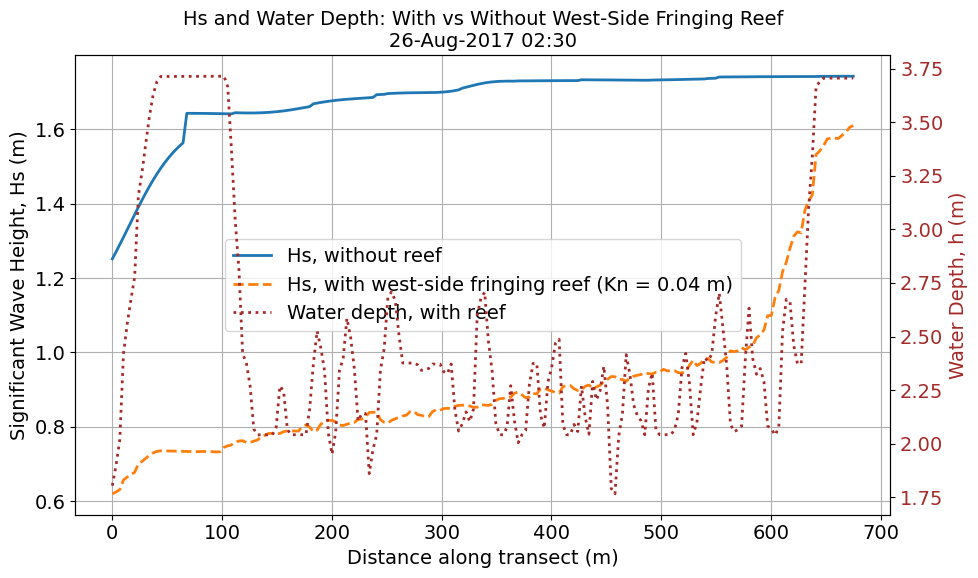

In [27]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_with_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef.sw - Result Files\west_side_fringing_reef.dfsu"

dfsu_without_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 730232, 3175335

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_with_reef, time_with_reef = extract_profile(
    dfsu_with_reef,
    "Sign. Wave Height"
)

hs_without_reef, time_without_reef = extract_profile(
    dfsu_without_reef,
    "Sign. Wave Height"
)

# Extract only with-reef water depth
depth_with_reef, time_depth_with = extract_profile(
    dfsu_with_reef,
    "Water depth"
)

print("Selected timestep with reef:", time_with_reef)
print("Selected timestep without reef:", time_without_reef)
print("Selected timestep water depth with reef:", time_depth_with)

# Plot Hs and with-reef water depth
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: Significant wave height
ax1.plot(
    distance,
    hs_without_reef,
    linewidth=2,
    label="Hs, without reef"
)

ax1.plot(
    distance,
    hs_with_reef,
    linewidth=2,
    linestyle="--",
    label="Hs, with west-side fringing reef (Kn = 0.04 m)"
)

ax1.set_xlabel("Distance along transect (m)")
ax1.set_ylabel("Significant Wave Height, Hs (m)")
ax1.grid(True)

# Secondary axis: Water depth with reef only
ax2 = ax1.twinx()

ax2.plot(
    distance,
    depth_with_reef,
    linewidth=2,
    color="brown",
    linestyle=":",
    label="Water depth, with reef"
)

ax2.set_ylabel("Water Depth, h (m)", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    frameon=True
)

plt.title("Hs and Water Depth: With vs Without West-Side Fringing Reef\n26-Aug-2017 02:30")

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected timestep for Water depth: 2017-08-26T02:30:00.000000000


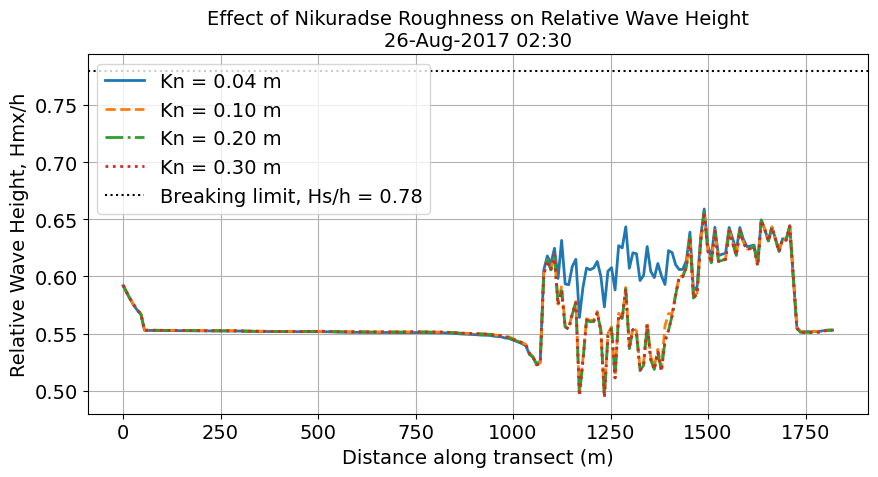

In [28]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

# Change this path if your Kn = 0.30 m file is different
dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_004, time_004 = extract_profile(dfsu_file_004, "Max. Wave Height")
hs_01,  time_01  = extract_profile(dfsu_file_01,  "Max. Wave Height")
hs_02,  time_02  = extract_profile(dfsu_file_02,  "Max. Wave Height")
hs_03,  time_03  = extract_profile(dfsu_file_03,  "Max. Wave Height")

# Extract water depth profile
# Using Kn = 0.04 m file because water depth should be identical across roughness cases
depth_profile, time_depth = extract_profile(dfsu_file_004, "Water depth")

# Avoid division by zero or dry elements
depth_profile = np.where(depth_profile > 0.01, depth_profile, np.nan)

# Calculate relative wave height Hs/h
ratio_004 = hs_004 / depth_profile
ratio_01  = hs_01  / depth_profile
ratio_02  = hs_02  / depth_profile
ratio_03  = hs_03  / depth_profile

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected timestep for Water depth:", time_depth)

# Plot only relative wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

# Optional breaking threshold
plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hs/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hmx/h")
plt.title("Effect of Nikuradse Roughness on Relative Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected water-depth timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected water-depth timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected water-depth timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000
Selected water-depth timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


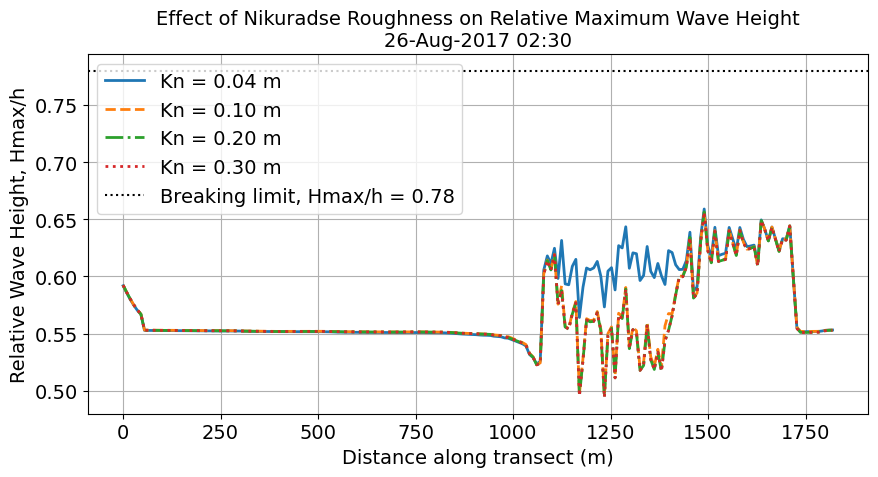

In [29]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

target_time = np.datetime64("2017-08-26T02:30:00")

distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

def safe_depth(depth):
    return np.where(depth > 0.01, depth, np.nan)

# Extract Hmax and corresponding water depth for each file
hmax_004, time_004 = extract_profile(dfsu_file_004, "Max. Wave Height")
depth_004, time_depth_004 = extract_profile(dfsu_file_004, "Water depth")

hmax_01, time_01 = extract_profile(dfsu_file_01, "Max. Wave Height")
depth_01, time_depth_01 = extract_profile(dfsu_file_01, "Water depth")

hmax_02, time_02 = extract_profile(dfsu_file_02, "Max. Wave Height")
depth_02, time_depth_02 = extract_profile(dfsu_file_02, "Water depth")

hmax_03, time_03 = extract_profile(dfsu_file_03, "Max. Wave Height")
depth_03, time_depth_03 = extract_profile(dfsu_file_03, "Water depth")

# Calculate Hmax / h for each corresponding file
ratio_004 = hmax_004 / safe_depth(depth_004)
ratio_01  = hmax_01  / safe_depth(depth_01)
ratio_02  = hmax_02  / safe_depth(depth_02)
ratio_03  = hmax_03  / safe_depth(depth_03)

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected water-depth timestep for Kn = 0.04 m:", time_depth_004)

print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected water-depth timestep for Kn = 0.10 m:", time_depth_01)

print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected water-depth timestep for Kn = 0.20 m:", time_depth_02)

print("Selected timestep for Kn = 0.30 m:", time_03)
print("Selected water-depth timestep for Kn = 0.30 m:", time_depth_03)

# Plot relative maximum wave height
plt.figure(figsize=(9, 5))

plt.plot(distance, ratio_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, ratio_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, ratio_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, ratio_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.axhline(
    y=0.78,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Breaking limit, Hmax/h = 0.78"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Relative Wave Height, Hmax/h")
plt.title("Effect of Nikuradse Roughness on Relative Maximum Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

Selected timestep for Kn = 0.04 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.10 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.20 m: 2017-08-26T02:30:00.000000000
Selected timestep for Kn = 0.30 m: 2017-08-26T02:30:00.000000000


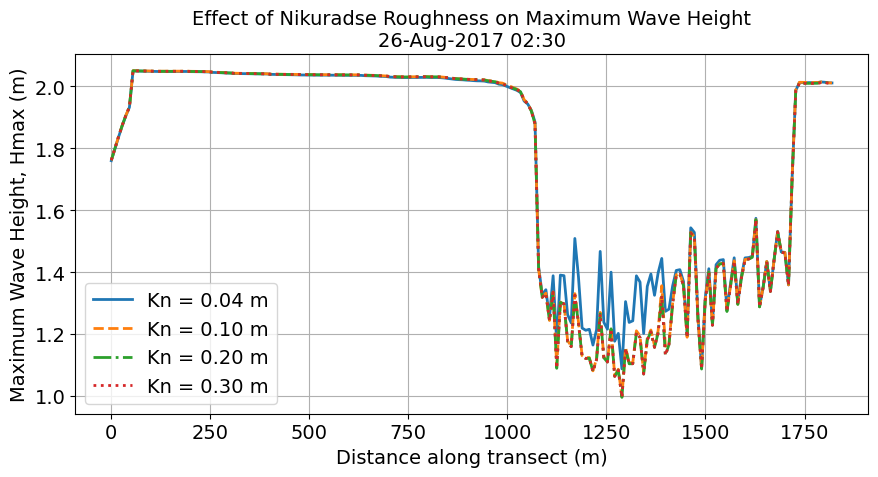

In [31]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_file_004 = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

dfsu_file_01 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.1m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.1m.dfsu"

dfsu_file_02 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.2m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.2m.dfsu"

dfsu_file_03 = r"E:\PhD Research-2\Reef and Wave\Small_scale_wave_result_files\sensitivity\West_side_barrier_reef_with_roughness_0.3m.sw - Result Files\small_scale_wave_result_with_barrier_reef_roughness_0.3m.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 731393, 3175721

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Maximum Wave Height profiles
hmax_004, time_004 = extract_profile(dfsu_file_004, "Max. Wave Height")
hmax_01,  time_01  = extract_profile(dfsu_file_01,  "Max. Wave Height")
hmax_02,  time_02  = extract_profile(dfsu_file_02,  "Max. Wave Height")
hmax_03,  time_03  = extract_profile(dfsu_file_03,  "Max. Wave Height")

print("Selected timestep for Kn = 0.04 m:", time_004)
print("Selected timestep for Kn = 0.10 m:", time_01)
print("Selected timestep for Kn = 0.20 m:", time_02)
print("Selected timestep for Kn = 0.30 m:", time_03)

# Plot Maximum Wave Height
plt.figure(figsize=(9, 5))

plt.plot(distance, hmax_004, linewidth=2, label="Kn = 0.04 m")
plt.plot(distance, hmax_01,  linewidth=2, linestyle="--", label="Kn = 0.10 m")
plt.plot(distance, hmax_02,  linewidth=2, linestyle="-.", label="Kn = 0.20 m")
plt.plot(distance, hmax_03,  linewidth=2, linestyle=":", label="Kn = 0.30 m")

plt.xlabel("Distance along transect (m)")
plt.ylabel("Maximum Wave Height, Hmax (m)")
plt.title("Effect of Nikuradse Roughness on Maximum Wave Height\n26-Aug-2017 02:30")

plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()